In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
%matplotlib inline

In [8]:
df = pd.read_csv('Breast_cancer_data.csv')

In [9]:
df.keys()

Index(['mean_radius', 'mean_texture', 'mean_perimeter', 'mean_area',
       'mean_smoothness', 'diagnosis'],
      dtype='object')

In [11]:
df.head(5)

,mean_radius,mean_texture,mean_perimeter,mean_area,mean_smoothness,diagnosis
0,17.99,10.38,122.80,1001.0,0.11840,0
1,20.57,17.77,132.90,1326.0,0.08474,0
2,19.69,21.25,130.00,1203.0,0.10960,0
3,11.42,20.38,77.58,386.1,0.14250,0
4,20.29,14.34,135.10,1297.0,0.10030,0


In [12]:
from sklearn.preprocessing import MinMaxScaler

In [13]:
from sklearn.preprocessing import StandardScaler

In [14]:
scaler=StandardScaler()
scaler.fit(df)

,copy,True
,with_mean,True
,with_std,True


In [15]:
scaled_data=scaler.transform(df)

In [16]:
scaled_data

array([[ 1.09706398, -2.07333501,  1.26993369,  0.9843749 ,  1.56846633,
        -1.29767572],
       [ 1.82982061, -0.35363241,  1.68595471,  1.90870825, -0.82696245,
        -1.29767572],
       [ 1.57988811,  0.45618695,  1.56650313,  1.55888363,  0.94221044,
        -1.29767572],
       ...,
       [ 0.70228425,  2.0455738 ,  0.67267578,  0.57795264, -0.84048388,
        -1.29767572],
       [ 1.83834103,  2.33645719,  1.98252415,  1.73521799,  1.52576706,
        -1.29767572],
       [-1.80840125,  1.22179204, -1.81438851, -1.34778924, -3.11208479,
         0.77060855]])

In [17]:
from sklearn.decomposition import PCA

In [18]:
pca=PCA(n_components=2)

In [19]:
pca.fit(scaled_data)

,n_components,2
,copy,True
,whiten,False
,svd_solver,'auto'
,tol,0.0
,iterated_power,'auto'
,n_oversamples,10
,power_iteration_normalizer,'auto'
,random_state,None


In [20]:
x_pca=pca.transform(scaled_data)

In [21]:
scaled_data.shape

(569, 6)

In [22]:
x_pca.shape

(569, 2)

In [23]:
scaled_data

array([[ 1.09706398, -2.07333501,  1.26993369,  0.9843749 ,  1.56846633,
        -1.29767572],
       [ 1.82982061, -0.35363241,  1.68595471,  1.90870825, -0.82696245,
        -1.29767572],
       [ 1.57988811,  0.45618695,  1.56650313,  1.55888363,  0.94221044,
        -1.29767572],
       ...,
       [ 0.70228425,  2.0455738 ,  0.67267578,  0.57795264, -0.84048388,
        -1.29767572],
       [ 1.83834103,  2.33645719,  1.98252415,  1.73521799,  1.52576706,
        -1.29767572],
       [-1.80840125,  1.22179204, -1.81438851, -1.34778924, -3.11208479,
         0.77060855]])

In [24]:
x_pca

array([[ 1.97568481,  2.34730684],
       [ 3.04023374, -0.65577132],
       [ 3.1396354 ,  0.52733517],
       ...,
       [ 1.88078266, -1.63646057],
       [ 4.08698311,  0.09635452],
       [-2.97849615, -3.12926935]])

In [27]:
plt.figure(figsize=(8,6))
plt.scatter(x_pca[:,0],x_pca[:,1],c=df['diagnosis'])
plt.xlabel('First principle component')
plt.ylabel('Second principle component')

Text(0, 0.5, 'Second principle component')

In [28]:
X = df.drop('diagnosis', axis=1)   # features
y = df['diagnosis']               # labels


In [29]:
from sklearn.decomposition import PCA

pca = PCA()
pca.fit(scaled_data)

explained_var = np.cumsum(pca.explained_variance_ratio_)
plt.plot(explained_var)
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.grid()


In [30]:
pca_opt = PCA(n_components=2)   # example: 2 components for visualization
X_pca = pca_opt.fit_transform(scaled_data)


<Figure size 800x600 with 0 Axes>

<Figure size 800x600 with 0 Axes>

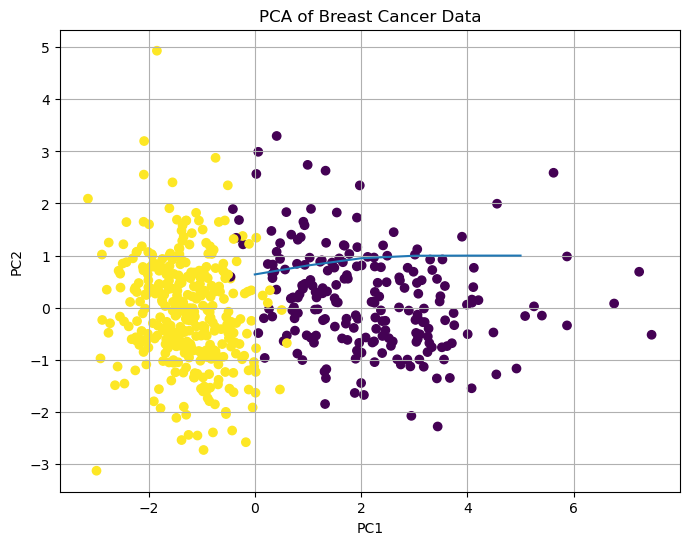

In [31]:
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y.map({'M':1, 'B':0}), cmap='coolwarm')
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA of Breast Cancer Data")
plt.show()


In [35]:
X = df.drop('diagnosis', axis=1)
y = df['diagnosis']

scaled_data = scaler.fit_transform(X)
pca_opt = PCA(n_components=2)
X_pca = pca_opt.fit_transform(scaled_data)

pd.DataFrame(pca_opt.components_, columns=X.columns, index=['PC1','PC2'])


,mean_radius,mean_texture,mean_perimeter,mean_area,mean_smoothness
PC1,0.553713,0.246878,0.555620,0.551790,0.138804
PC2,-0.002694,-0.533564,0.024738,0.003859,0.845385


In [36]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

X_train, X_test, y_train, y_test = train_test_split(X_pca, y, test_size=0.2, random_state=42)

model = LogisticRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print("Accuracy after PCA:", accuracy_score(y_test, y_pred))


Accuracy after PCA: 0.9298245614035088
